# Problem set 1 for AMAS

by: Aske Roelshøj (KVF851)

In [82]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

## Problem 1 

In [83]:
#Let us load the KenPomeroy data using Pandas: 
kenpom_2014 = pd.read_html("kenpom_2014.html", header = 17)[0] 
kenpom_2014

,Rk,Team,Conf,W-L,NetRtg,ORtg,ORtg.1,DRtg,DRtg.1,AdjT,...,Luck,Luck.1,NetRtg.1,NetRtg.2,ORtg.2,ORtg.3,DRtg.2,DRtg.3,NetRtg.3,NetRtg.4
0,2,Arizona 1,P12,33-5,+30.11,116.5,20,86.4,1,62.8,...,+.014,151,+9.30,17,109.9,20,100.6,18,+1.62,113
1,19,Ohio St. 6,B10,25-10,+21.30,109.3,103,88.0,2,64.0,...,-.043,275,+7.80,39,109.2,36,101.4,50,-3.36,267
2,3,Florida 1,SEC,36-3,+28.57,116.5,19,88.0,3,61.3,...,+.053,68,+9.02,22,109.4,32,100.4,14,+2.39,94
3,4,Virginia 1,ACC,30-7,+26.46,114.8,27,88.3,4,59.5,...,+.012,154,+8.67,28,109.4,31,100.8,27,+1.57,114
4,1,Louisville 4,Amer,31-6,+30.41,118.9,7,88.5,5,67.2,...,-.045,278,+4.31,95,107.0,100,102.7,93,-4.65,295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,319,LIU Brooklyn,NEC,9-20,-15.55,103.0,213,118.6,347,66.4,...,+.077,28,-4.62,253,102.1,296,106.7,227,-1.58,209
363,336,Maryland Eastern Shore,MEAC,6-24,-20.22,99.1,275,119.3,348,65.1,...,-.036,258,-7.27,313,99.8,337,107.1,250,+0.93,132
364,349,Presbyterian,BSth,6-26,-25.87,94.2,328,120.0,349,63.5,...,-.017,221,-7.84,324,101.7,307,109.6,326,-7.05,328
365,340,Cornell,Ivy,2-26,-20.58,100.4,260,120.9,350,63.6,...,-.048,288,+1.40,120,104.9,152,103.5,103,+1.19,124


In [84]:
#Function to remove repeating label rows: 
def data_cleaner(df):
    df['Rk'] = pd.to_numeric(df['Rk'], errors='coerce')
    df['Team'] = df['Team'].str.strip("0123456789 ")
    df['Team'] = df['Team'].str.strip(".")
    df['DRtg'] = pd.to_numeric(df['DRtg'], errors='coerce')
    df['ORtg'] = pd.to_numeric(df['ORtg'], errors='coerce')
    df = df.dropna().reset_index(drop=True)
    return df

kenpom_2014 = data_cleaner(kenpom_2014)
kenpom_2014

,Rk,Team,Conf,W-L,NetRtg,ORtg,ORtg.1,DRtg,DRtg.1,AdjT,...,Luck,Luck.1,NetRtg.1,NetRtg.2,ORtg.2,ORtg.3,DRtg.2,DRtg.3,NetRtg.3,NetRtg.4
0,2.0,Arizona,P12,33-5,+30.11,116.5,20,86.4,1,62.8,...,+.014,151,+9.30,17,109.9,20,100.6,18,+1.62,113
1,19.0,Ohio St,B10,25-10,+21.30,109.3,103,88.0,2,64.0,...,-.043,275,+7.80,39,109.2,36,101.4,50,-3.36,267
2,3.0,Florida,SEC,36-3,+28.57,116.5,19,88.0,3,61.3,...,+.053,68,+9.02,22,109.4,32,100.4,14,+2.39,94
3,4.0,Virginia,ACC,30-7,+26.46,114.8,27,88.3,4,59.5,...,+.012,154,+8.67,28,109.4,31,100.8,27,+1.57,114
4,1.0,Louisville,Amer,31-6,+30.41,118.9,7,88.5,5,67.2,...,-.045,278,+4.31,95,107.0,100,102.7,93,-4.65,295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,319.0,LIU Brooklyn,NEC,9-20,-15.55,103.0,213,118.6,347,66.4,...,+.077,28,-4.62,253,102.1,296,106.7,227,-1.58,209
347,336.0,Maryland Eastern Shore,MEAC,6-24,-20.22,99.1,275,119.3,348,65.1,...,-.036,258,-7.27,313,99.8,337,107.1,250,+0.93,132
348,349.0,Presbyterian,BSth,6-26,-25.87,94.2,328,120.0,349,63.5,...,-.017,221,-7.84,324,101.7,307,109.6,326,-7.05,328
349,340.0,Cornell,Ivy,2-26,-20.58,100.4,260,120.9,350,63.6,...,-.048,288,+1.40,120,104.9,152,103.5,103,+1.19,124


In [85]:
#We are only interested in ACC, SEC, B10, BSky and A10. 
conf_names = ['ACC', 'SEC', 'B10', 'BSky', 'A10']
colors = ['blue', 'orange', 'green', 'red', 'purple']
hatches = ['*', '||', '-', 'o', '//']

def data_by_conf(df, conf_names):
    df = df[df['Conf'].isin(conf_names)]
    return df

kenpom_2014_confs = data_by_conf(kenpom_2014, conf_names)

DRtg_byconf_2014 = kenpom_2014_confs.groupby('Conf')['DRtg']
DRtg_2014 = DRtg_byconf_2014.apply(list)

DRtg_2014

Conf
A10     [89.4, 90.0, 96.5, 97.0, 97.3, 99.3, 99.4, 99....
ACC     [88.3, 93.0, 93.7, 94.2, 95.0, 95.2, 97.4, 99....
B10     [88.0, 93.4, 94.7, 94.9, 96.1, 96.1, 96.2, 99....
BSky    [107.0, 108.1, 108.5, 111.3, 111.6, 111.7, 111...
SEC     [88.0, 94.2, 95.8, 95.9, 96.9, 98.5, 98.6, 99....
Name: DRtg, dtype: object

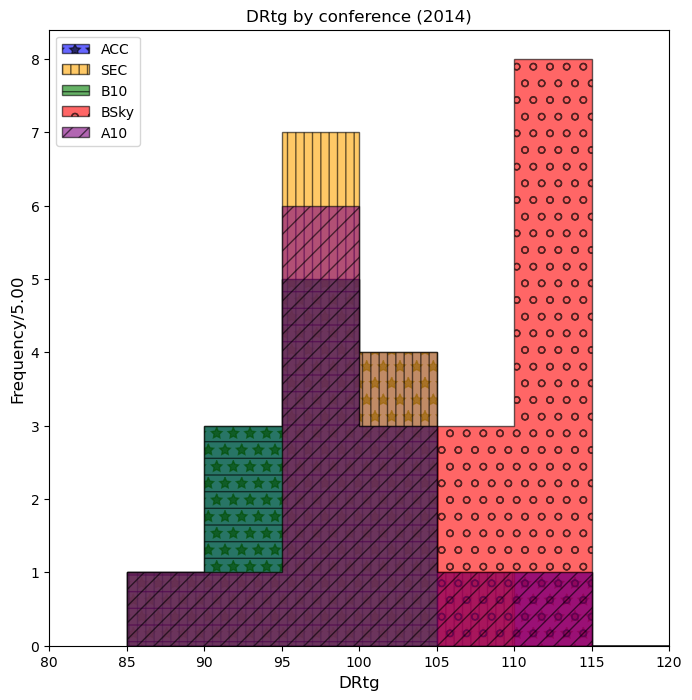

In [86]:
#Lets us plot the histograms of DRtg for each conference: 
x_diff = 125-85 
N_bins = 8
binwidth = x_diff / N_bins
fig, ax = plt.subplots(figsize = (8, 8))
for i, name in enumerate(conf_names):
    data = pd.to_numeric(pd.Series(DRtg_2014[name]), errors="coerce").dropna().to_numpy()
    counts, bin_edges = np.histogram(data, bins=N_bins, range=(85, 125))
    x = 0.5 * (bin_edges[:-1] + bin_edges[1:])[counts > 0]
    y = counts[counts > 0]
    hist = ax.hist(data, bins=N_bins, histtype = 'stepfilled', color = colors[i], hatch = hatches[i], edgecolor = 'k',range=(85, 125), alpha = 0.6,label=name)

plt.xlabel('DRtg', fontsize = 12)
plt.ylabel(f'Frequency/{binwidth:.2f}', fontsize=12)
plt.title('DRtg by conference (2014)', fontsize=12)
plt.xlim(80, 120)
plt.legend()
plt.show()


## Problem 2

In [87]:
kenpom_2009 = pd.read_html("kenpom_2009.html", header = 17)[0]
kenpom_2009 = data_cleaner(kenpom_2009)
kenpom_2009

,Rk,Team,Conf,W-L,NetRtg,ORtg,ORtg.1,DRtg,DRtg.1,AdjT,...,Luck,Luck.1,NetRtg.1,NetRtg.2,ORtg.2,ORtg.3,DRtg.2,DRtg.3,NetRtg.3,NetRtg.4
0,4.0,Memphis,CUSA,33-4,+28.67,112.8,37,84.2,1,65.9,...,-.009,190,+4.73,77,105.5,73,100.8,78,+4.19,67
1,5.0,Louisville,BE,31-6,+26.06,111.2,49,85.2,2,66.9,...,+.068,25,+9.57,27,108.6,17,99.0,37,-0.19,161
2,2.0,Connecticut,BE,31-5,+29.25,116.0,17,86.8,3,67.1,...,+.024,107,+10.37,13,109.0,11,98.6,24,-1.68,200
3,25.0,Illinois,B10,24-10,+18.72,106.8,104,88.1,4,62.8,...,+.001,164,+7.96,45,106.5,55,98.6,23,-3.36,239
4,18.0,Purdue,B10,27-10,+21.84,110.5,60,88.7,5,65.9,...,-.012,199,+8.94,36,107.2,46,98.3,16,-5.45,289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,333.0,Bryant,ind,8-21,-20.61,94.0,296,114.6,340,61.0,...,+.027,96,-6.04,289,98.5,303,104.5,228,-4.14,256
340,336.0,Southeast Missouri St,OVC,3-27,-21.81,95.0,288,116.8,341,69.7,...,-.017,218,-3.10,224,102.8,170,105.9,295,-1.74,203
341,342.0,Maryland Eastern Shore,MEAC,7-23,-27.77,89.2,336,116.9,342,63.5,...,+.060,34,-12.24,343,93.7,344,105.9,298,-9.51,332
342,341.0,Grambling St,SWAC,6-23,-27.10,89.8,330,116.9,343,61.8,...,-.015,210,-10.00,330,96.6,329,106.6,320,+4.77,56


In [88]:
#Match common teams in 2009 and 2014:
kenpom_byteams_2009 = kenpom_2009[kenpom_2009['Team'].isin(kenpom_2014['Team'])]
kenpom_byteams_2014 = kenpom_2014[kenpom_2014['Team'].isin(kenpom_2009['Team'])]

#Now sort: 
kenpom_byteams_2009 = kenpom_byteams_2009.sort_values('Team').reset_index(drop=True)
kenpom_byteams_2014 = kenpom_byteams_2014.sort_values('Team').reset_index(drop=True)

In [89]:
#Making a new merged dataframe:
merged_df = pd.DataFrame({
    'Team': kenpom_byteams_2009['Team'],
    'Conf_2009': kenpom_byteams_2009['Conf'],
    'Conf_2014': kenpom_byteams_2014['Conf'],
    'ORtg_2009': kenpom_byteams_2009['ORtg'],
    'ORtg_2014': kenpom_byteams_2014['ORtg']
})

#Add new column: 
merged_df['delta_ORtg'] = merged_df['ORtg_2014'] - merged_df['ORtg_2009']
print(merged_df)
no_switch_ORtg = merged_df[merged_df['Conf_2009'] == merged_df['Conf_2014']]

delta_ORtg_byconf = no_switch_ORtg.groupby('Conf_2009')['delta_ORtg']
delta_ORtg_byconf = delta_ORtg_byconf.apply(list)

ORtg_byconf_2009 = no_switch_ORtg.groupby('Conf_2009')['ORtg_2009']
ORtg_byconf_2009 = ORtg_byconf_2009.apply(list)
no_switch_ORtg = no_switch_ORtg.dropna().reset_index(drop = True)
no_switch_ORtg

              Team Conf_2009 Conf_2014  ORtg_2009  ORtg_2014  delta_ORtg
0        Air Force       MWC       MWC       98.6       99.6         1.0
1            Akron       MAC       MAC      102.9      105.0         2.1
2          Alabama       SEC       SEC      105.9      107.8         1.9
3      Alabama A&M      SWAC      SWAC       86.0       92.0         6.0
4       Alabama St      SWAC      SWAC      100.7       97.3        -3.4
..             ...       ...       ...        ...        ...         ...
337      Wright St      Horz      Horz      100.7      100.4        -0.3
338        Wyoming       MWC       MWC      107.0      105.5        -1.5
339         Xavier       A10        BE      111.0      112.9         1.9
340           Yale       Ivy       Ivy       95.3      102.8         7.5
341  Youngstown St      Horz      Horz      101.5      107.9         6.4

[342 rows x 6 columns]


,Team,Conf_2009,Conf_2014,ORtg_2009,ORtg_2014,delta_ORtg
0,Air Force,MWC,MWC,98.6,99.6,1.0
1,Akron,MAC,MAC,102.9,105.0,2.1
2,Alabama,SEC,SEC,105.9,107.8,1.9
3,Alabama A&M,SWAC,SWAC,86.0,92.0,6.0
4,Alabama St,SWAC,SWAC,100.7,97.3,-3.4
...,...,...,...,...,...,...
259,Wofford,SC,SC,106.3,100.6,-5.7
260,Wright St,Horz,Horz,100.7,100.4,-0.3
261,Wyoming,MWC,MWC,107.0,105.5,-1.5
262,Yale,Ivy,Ivy,95.3,102.8,7.5


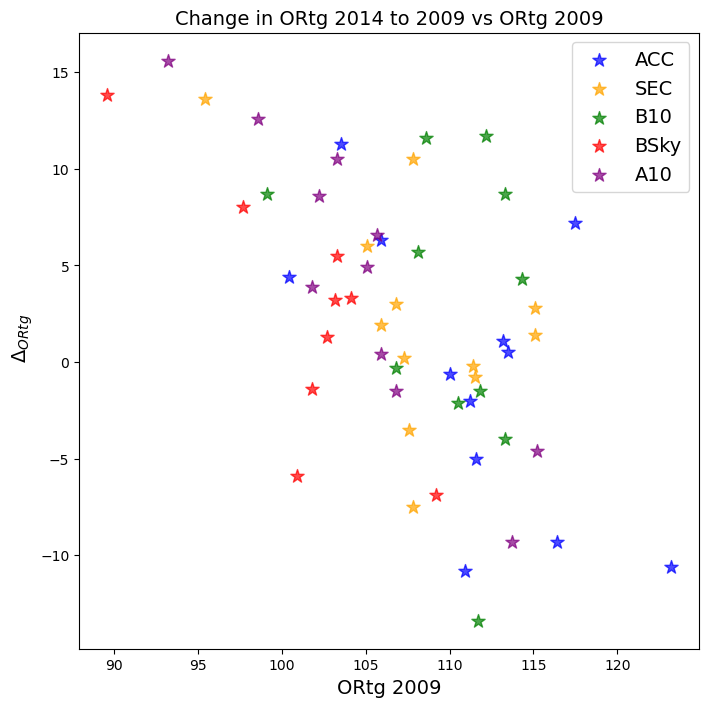

In [90]:
#Make a scatterplot: 
fig, ax = plt.subplots(figsize=(8, 8))
for i, conf in enumerate(conf_names):
    x = ORtg_byconf_2009[conf]
    y = delta_ORtg_byconf[conf]
    ax.scatter(x, y, marker = '*', s=100, color=colors[i], label=conf, alpha=0.7)
plt.xlabel('ORtg 2009', fontsize=14)
plt.ylabel(r' $\Delta_{ORtg}$', fontsize=14)
plt.title('Change in ORtg 2014 to 2009 vs ORtg 2009', fontsize=14)
plt.legend(fontsize = 14)
plt.show()

In [91]:
def jackknife_sampl(data):
    n = len(data)
    jackknife_samples = np.empty((n, n-1))
    medians = []
    for i in range(n):
        jackknife_samples[i] = np.delete(data, i)
        median = np.median(jackknife_samples[i])
        medians.append(median)
    var  = (n-1) * np.var(medians)
    std = np.sqrt(var)
    return std

In [92]:
#Calculate mean and median delta_ORtg for each conference:
def mean_median_confs():
    for conf in conf_names:
        mean_delta = np.mean(delta_ORtg_byconf[conf])
        mean_unc = np.std(delta_ORtg_byconf[conf]) / np.sqrt(len(delta_ORtg_byconf[conf]))
        median_delta = np.median(delta_ORtg_byconf[conf])
        median_std = jackknife_sampl(delta_ORtg_byconf[conf])
        print(f"{conf}: Mean delta_ORtg = ({mean_delta:.3f} pm {mean_unc:.3f}), Median delta_ORtg = ({median_delta:.3f} pm {median_std:.3f})")
    return

mean_median_confs()


ACC: Mean delta_ORtg = (-0.625 pm 2.007), Median delta_ORtg = (-0.050 pm 1.824)
SEC: Mean delta_ORtg = (2.283 pm 1.582), Median delta_ORtg = (1.650 pm 0.829)
B10: Mean delta_ORtg = (2.673 pm 2.222), Median delta_ORtg = (4.300 pm 4.581)
BSky: Mean delta_ORtg = (2.322 pm 2.059), Median delta_ORtg = (3.200 pm 1.392)
A10: Mean delta_ORtg = (4.336 pm 2.175), Median delta_ORtg = (4.900 pm 2.041)


In [93]:
#Calculate mean and median delta_ORtg for all other conferences: 
def mean_median_otherconfs():
    other_confs = merged_df[~merged_df["Conf_2009"].isin(conf_names)]
    mean_other = other_confs["delta_ORtg"].mean()
    mean_unc_other = other_confs['delta_ORtg'].std()/np.sqrt(len(other_confs['delta_ORtg']))

    median_other = other_confs["delta_ORtg"].median()
    median_unc_other = jackknife_sampl(other_confs['delta_ORtg'])

    #Print the values: 
    print(f'Mean delta ORtg for other confs: ({mean_other:.3f} pm {mean_unc_other:.3f}) and median: ({median_other} pm {median_unc_other})')
    return

mean_median_otherconfs()


Mean delta ORtg for other confs: (2.402 pm 0.412) and median: (1.3000000000000043 pm 1.1953178955977764e-13)


## Problem 3 

In [94]:
#Now lets redo Prob 1 and 2 with BE as an extra conference. 
conf_names_new = conf_names + ['BE']
hatches = hatches + ['.']
colors = colors + ['slategrey']

print(conf_names_new)

['ACC', 'SEC', 'B10', 'BSky', 'A10', 'BE']


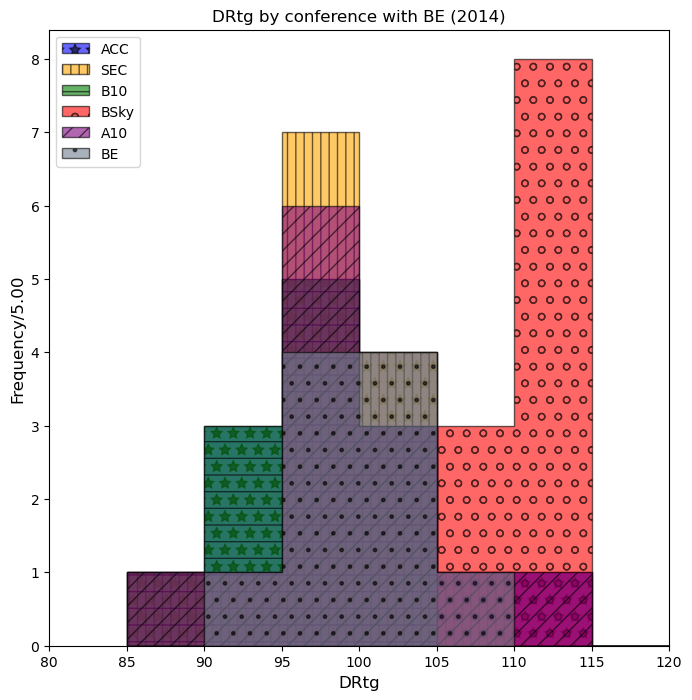

In [95]:
#First the histogram: 
kenpom_2014_newconfs = data_by_conf(kenpom_2014, conf_names_new)
DRtg_byconf_2014_newconfs = kenpom_2014_newconfs.groupby('Conf')['DRtg']
DRtg_2014_newconfs = DRtg_byconf_2014_newconfs.apply(list)

fig, ax = plt.subplots(figsize = (8, 8))
for i, name in enumerate(conf_names_new):
    data = pd.to_numeric(pd.Series(DRtg_2014_newconfs[name]), errors="coerce").dropna().to_numpy()
    counts, bin_edges = np.histogram(data, bins=N_bins, range=(85, 125))
    x = 0.5 * (bin_edges[:-1] + bin_edges[1:])[counts > 0]
    y = counts[counts > 0]
    hist = ax.hist(data, bins=N_bins, histtype = 'stepfilled', color = colors[i], hatch = hatches[i], edgecolor = 'k',range=(85, 125), alpha = 0.6,label=name)

plt.xlabel('DRtg', fontsize = 12)
plt.ylabel(f'Frequency/{binwidth:.2f}', fontsize=12)
plt.title('DRtg by conference with BE (2014)', fontsize=12)
plt.xlim(80, 120)
plt.legend()
plt.show()

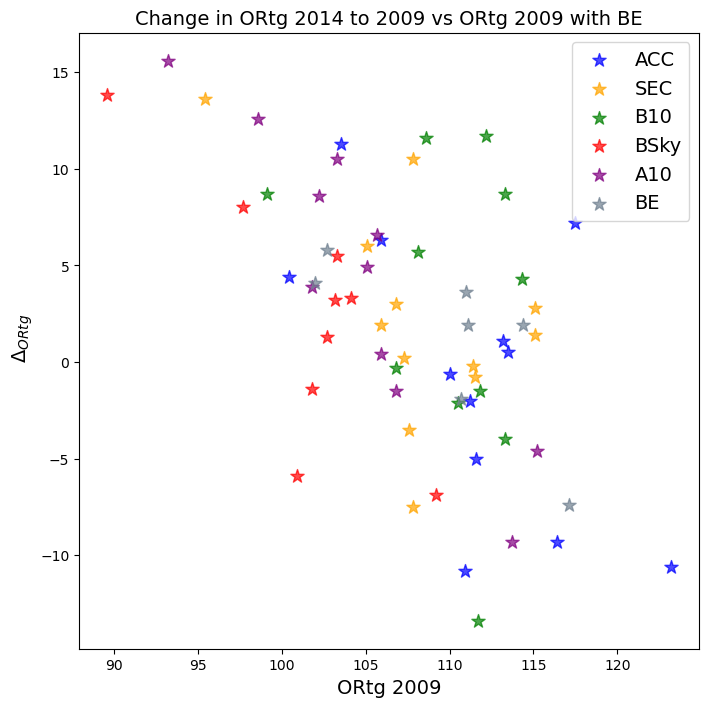

In [96]:
#Now the difference in ORtg: 
fig, ax = plt.subplots(figsize=(8, 8))
for i, conf in enumerate(conf_names_new):
    x = ORtg_byconf_2009[conf]
    y = delta_ORtg_byconf[conf]
    ax.scatter(x, y, marker = '*', s=100, color=colors[i], label=conf, alpha=0.7)
plt.xlabel('ORtg 2009', fontsize=14)
plt.ylabel(r' $\Delta_{ORtg}$', fontsize=14)
plt.title('Change in ORtg 2014 to 2009 vs ORtg 2009 with BE', fontsize=14)
plt.legend(fontsize = 14)
plt.show()

In [97]:
#Now calculate the mean and medians: 
def mean_median_newconf():
    for conf in conf_names_new:
        mean_delta = np.mean(delta_ORtg_byconf[conf])
        mean_unc = np.std(delta_ORtg_byconf[conf]) / np.sqrt(len(delta_ORtg_byconf[conf]))
        median_delta = np.median(delta_ORtg_byconf[conf])
        median_std = jackknife_sampl(delta_ORtg_byconf[conf])
        print(f"{conf}: Mean delta_ORtg = ({mean_delta:.3f} pm {mean_unc:.3f}), Median delta_ORtg = ({median_delta:.3f} pm {median_std:.3f})")
    return

mean_median_newconf()

ACC: Mean delta_ORtg = (-0.625 pm 2.007), Median delta_ORtg = (-0.050 pm 1.824)
SEC: Mean delta_ORtg = (2.283 pm 1.582), Median delta_ORtg = (1.650 pm 0.829)
B10: Mean delta_ORtg = (2.673 pm 2.222), Median delta_ORtg = (4.300 pm 4.581)
BSky: Mean delta_ORtg = (2.322 pm 2.059), Median delta_ORtg = (3.200 pm 1.392)
A10: Mean delta_ORtg = (4.336 pm 2.175), Median delta_ORtg = (4.900 pm 2.041)
BE: Mean delta_ORtg = (1.143 pm 1.564), Median delta_ORtg = (1.900 pm 1.030)


In [98]:
#And others:
def mean_median_otherconfs_new(): 
    other_confs = merged_df[~merged_df["Conf_2009"].isin(conf_names_new)]
    mean_other = other_confs["delta_ORtg"].mean()
    mean_unc_other = other_confs['delta_ORtg'].std()/np.sqrt(len(other_confs['delta_ORtg']))

    median_other = other_confs["delta_ORtg"].median()
    median_unc_other = jackknife_sampl(other_confs['delta_ORtg'])

    #Print the values: 
    print(f'Mean delta ORtg for other confs with BE: ({mean_other:.3f} pm {mean_unc_other:.3f}) and median: ({median_other} pm {median_unc_other})')
    return

mean_median_otherconfs_new()

Mean delta ORtg for other confs with BE: (2.488 pm 0.432) and median: (1.5 pm 3.268026927673453)
